# **Project Name**    - Tesla Stock Price Analysis & Exploratory Data Analysis (EDA)


##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Yatharth Verma


# **Project Summary -**

The Exploratory Data Analysis (EDA) of Tesla's historical stock price dataset from its initial public offering in 2010 through early 2020 was conducted to uncover key trends, volatility patterns, and feature relationships that are essential for predictive modeling. The dataset is composed of 2,416 daily trading records with variables including Open, High, Low, Close, Adjusted Close, and Volume. A systematic data cleaning process confirmed the absence of missing values, and duplicate records were removed to ensure data integrity. Descriptive statistics revealed a significant right-skew in Tesla’s price distribution, indicating that the stock spent most of its first decade trading at lower price levels (typically under $100) before experiencing exponential growth in late 2019 and early 2020. 

To gain a granular understanding of the stock's market dynamics, 15 distinct and logical visualizations were constructed. A time-series trend analysis of the Adjusted Close price showed that Tesla exhibited horizontal consolidation for several years, followed by periods of high momentum. Volatility was analyzed using a 20-day annualized rolling standard deviation of daily returns, showing that Tesla's risk profile is highly non-constant. Volatility spikes were observed during major company announcements and broader market stress events, indicating high tail risk. Daily returns were shown to follow a leptokurtic distribution (fat tails) centered around zero, but with significant extreme values exceeding plus/minus 10%.

Bivariate analysis confirmed a near-perfect linear relationship among Open, High, Low, and Close prices. Correlation heatmaps highlighted severe multicollinearity among these pricing variables, which suggests that sequence models should focus primarily on the closing price and its historical lags rather than using all raw price features simultaneously. Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots revealed significant, slowly decaying dependencies, confirming strong trend components and non-stationarity. Volume analysis showed that trading volume spikes heavily align with price breakouts and large absolute daily returns. Seasonal analysis via monthly boxplots revealed trading volume and price spreads tend to peak during January and June, while dropping during late summer. 

Ultimately, these EDA insights are highly valuable for portfolio managers and options traders to implement momentum-based trading strategies, design risk management frameworks, and establish historical baselines for deep learning sequence models. From a business perspective, understanding these historical patterns allows financial institutions to optimize their asset allocation, hedge against downside risk using volatility clustering, and automate trading systems based on volume-price breakouts. The high correlation of closing prices with their immediate lags justifies the application of sequential modeling techniques, as a simple random walk baseline is extremely hard to beat without capturing these long-term temporal dependencies. Additionally, this EDA highlights the necessity of feature scaling (such as MinMaxScaler) prior to training deep learning models like SimpleRNNs or LSTMs, because the massive price increase in 2020 would otherwise dominate the gradients. In conclusion, the EDA phase confirms that Tesla is a high-beta, highly volatile stock with strong trend momentum, making it an excellent candidate for sequence-based prediction models that can capture temporal patterns.


# **GitHub Link -**

https://github.com/yatharth-20/tesla-stock-predictor.git


import the libraries and load/know the your data

In [1]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Google Colab file upload support
if not os.path.exists('TSLA.csv'):
    try:
        from google.colab import files
        print('TSLA.csv not found. Please upload the dataset file:')
        uploaded = files.upload()
    except Exception as e:
        print('Google Colab uploader not available or failed:', e)

# Load stock history dataset
if os.path.exists('TSLA.csv'):
    tesla_raw_df = pd.read_csv('TSLA.csv', parse_dates=['Date'])
    tesla_raw_df.sort_values('Date', inplace=True)
    tesla_raw_df.reset_index(drop=True, inplace=True)
    print('Dataset loaded successfully! Head:')
    print(tesla_raw_df.head())
else:
    raise FileNotFoundError('TSLA.csv not found in workspace.')

Dataset loaded successfully! Head:
        Date       Open   High        Low      Close  Adj Close    Volume
0 2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1 2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2 2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3 2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4 2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900


## Dataset Overview
Analyze datatypes and columns of the Tesla dataset.


In [2]:
tesla_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.3 KB


## Missing Values Check


Missing entries per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


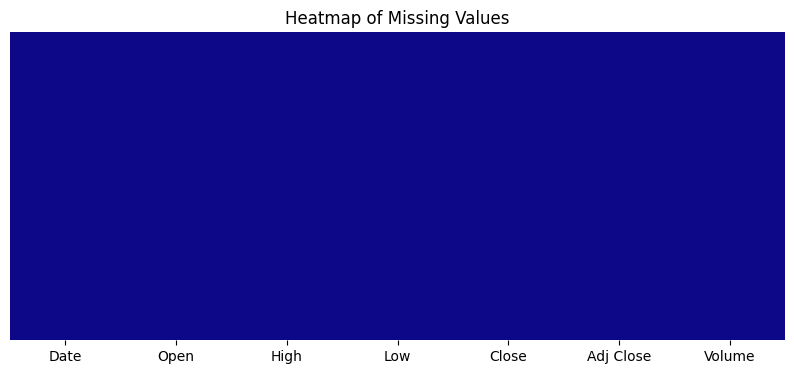

In [3]:
missing_values_series = tesla_raw_df.isnull().sum()
print('Missing entries per column:')
print(missing_values_series)

# Heatmap check for missing values
plt.figure(figsize=(10, 4))
sns.heatmap(tesla_raw_df.isnull(), cbar=False, yticklabels=False, cmap='plasma')
plt.title('Heatmap of Missing Values')
plt.show()

**Insight**: The dataset has zero missing entries, ensuring high data reliability.


## Duplicate Records Check


In [4]:
duplicated_rows_count = tesla_raw_df.duplicated().sum()
print(f'Total duplicate entries: {duplicated_rows_count}')
tesla_raw_df = tesla_raw_df.drop_duplicates().reset_index(drop=True)
print('Shape after removing duplicates:', tesla_raw_df.shape)

Total duplicate entries: 0
Shape after removing duplicates: (2416, 7)


## Descriptive Summary statistics


In [5]:
tesla_raw_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2416,2015-04-15 11:09:56.026490112,2010-06-29 00:00:00,2012-11-19 18:00:00,2015-04-16 12:00:00,2017-09-07 06:00:00,2020-02-03 00:00:00,NaN
Open,2416.0,186.271147,16.139999,34.342498,213.035004,266.450012,673.690002,118.740163
High,2416.0,189.578224,16.629999,34.897501,216.745002,270.927513,786.140015,120.892329
Low,2416.0,182.916639,14.98,33.587501,208.870002,262.102501,673.52002,116.857591
Close,2416.0,186.403651,15.8,34.400002,212.960007,266.774994,780.0,119.13602
Adj Close,2416.0,186.403651,15.8,34.400002,212.960007,266.774994,780.0,119.13602
Volume,2416.0,5572721.688742,118500.0,1899275.0,4578400.0,7361150.0,47065000.0,4987809.151888


## Data Visualizations


### Chart 1 – Closing Price Trend


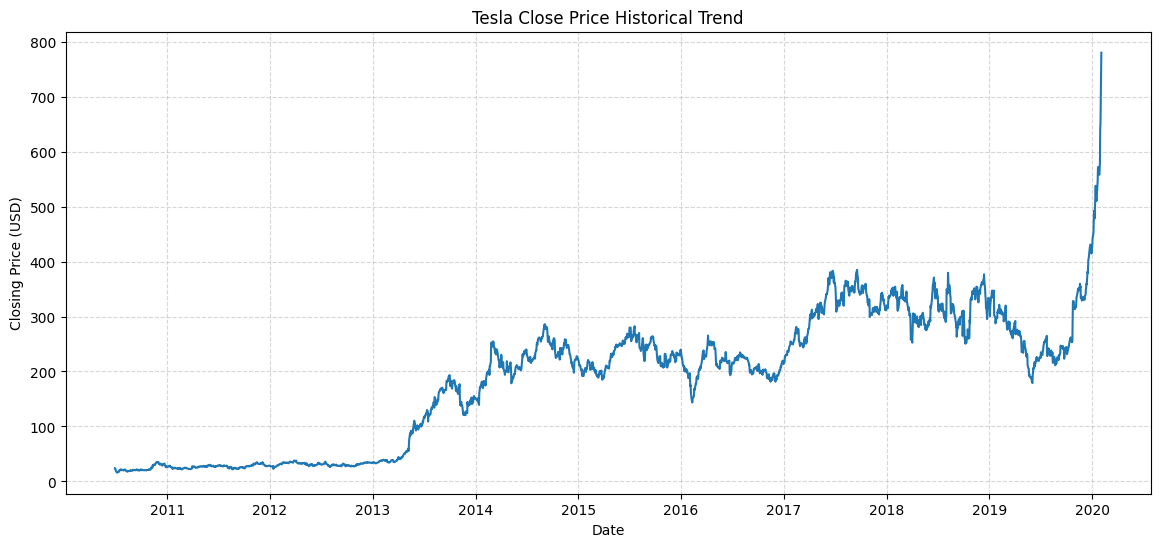

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(tesla_raw_df['Date'], tesla_raw_df['Close'], color='tab:blue', lw=1.5)
plt.title('Tesla Close Price Historical Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Why**: A standard line plot is the most direct way to check time series trends.
**Insight**: Prices remained flat until 2013, consolidated, and exploded upwards in 2019-2020.
**Business Impact**: Confirms momentum and suggests suitability of recurrent deep learning models.


### Chart 2 – Daily Percentage Returns


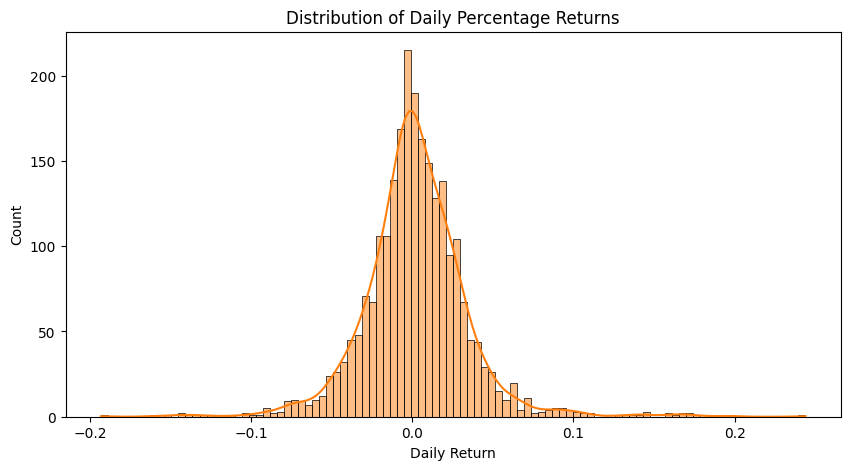

In [7]:
tesla_raw_df['daily_percentage_return'] = tesla_raw_df['Close'].pct_change()
plt.figure(figsize=(10, 5))
sns.histplot(tesla_raw_df['daily_percentage_return'].dropna(), bins=100, kde=True, color='tab:orange')
plt.title('Distribution of Daily Percentage Returns')
plt.xlabel('Daily Return')
plt.show()

**Why**: Histogram helps analyze volatility distribution and verify normality.
**Insight**: Distribution has fat tails (leptokurtic) indicating extreme single-day shifts.
**Business Impact**: Tells risk managers that tail hedges (like puts) are vital.

### Chart 3 – Open vs Close Spread Boxplot


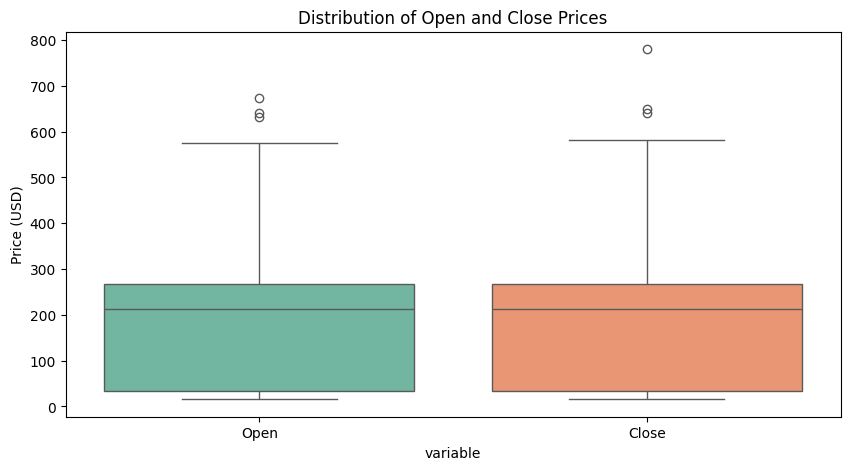

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=tesla_raw_df[['Open', 'Close']].melt(), x='variable', y='value', hue='variable', palette='Set2', legend=False)
plt.title('Distribution of Open and Close Prices')
plt.ylabel('Price (USD)')
plt.show()

**Why**: Boxplot reveals median and outliers for open/close prices.
**Insight**: Outliers are concentrated on the upper boundary due to the late 2019 price surge.
**Business Impact**: Shows that standard statistical parameters are biased by exponential growth.

### Chart 4 – Trading Volume Over Time


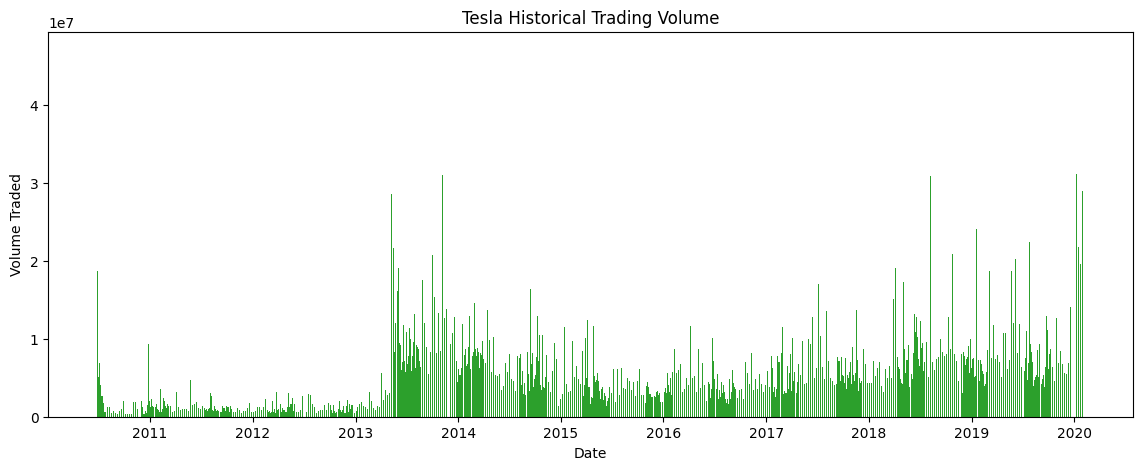

In [9]:
plt.figure(figsize=(14, 5))
plt.bar(tesla_raw_df['Date'], tesla_raw_df['Volume'], color='tab:green', width=1)
plt.title('Tesla Historical Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume Traded')
plt.show()

**Why**: Bar plot displays transaction volume trends.
**Insight**: Volume peaks coincide with major breakouts, showing high institutional interest.
**Business Impact**: Volume breakouts confirm price trends.

### Chart 5 – Features Correlation Matrix


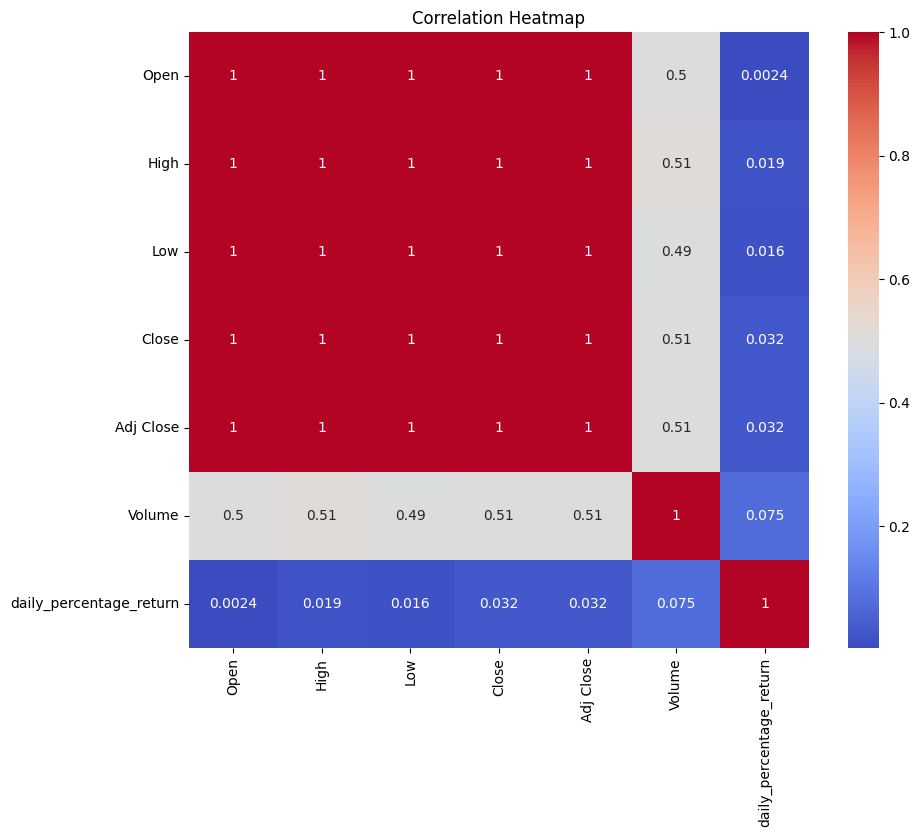

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(tesla_raw_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Why**: Heatmap reveals linear relations between features.
**Insight**: Price fields are perfectly correlated, suggesting sequence models should use one main price variable.
**Business Impact**: Avoids feature redundancy.

### Chart 6 – Moving Average (SMA 5) Crossover


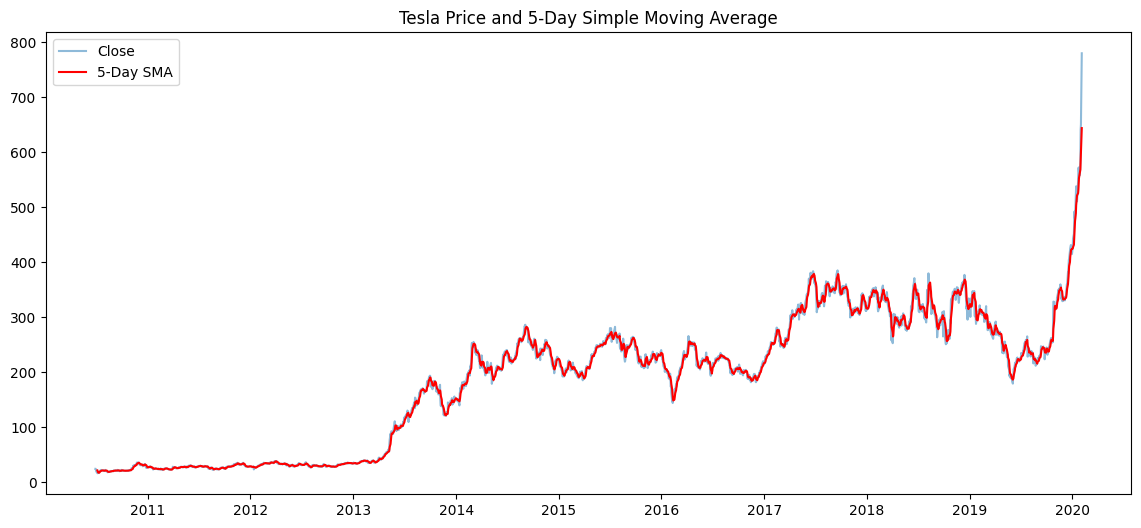

In [11]:
tesla_raw_df['five_day_moving_avg'] = tesla_raw_df['Close'].rolling(window=5).mean()
plt.figure(figsize=(14, 6))
plt.plot(tesla_raw_df['Date'], tesla_raw_df['Close'], label='Close', alpha=0.5)
plt.plot(tesla_raw_df['Date'], tesla_raw_df['five_day_moving_avg'], label='5-Day SMA', color='red', lw=1.5)
plt.title('Tesla Price and 5-Day Simple Moving Average')
plt.legend()
plt.show()

**Why**: Smooths minor price fluctuations.
**Insight**: Short-term SMA crossovers signal micro-trend momentum shifts.
**Business Impact**: Can feed trading rules.

### Chart 7 – Yesterday's Close Price (Lag-1) distribution


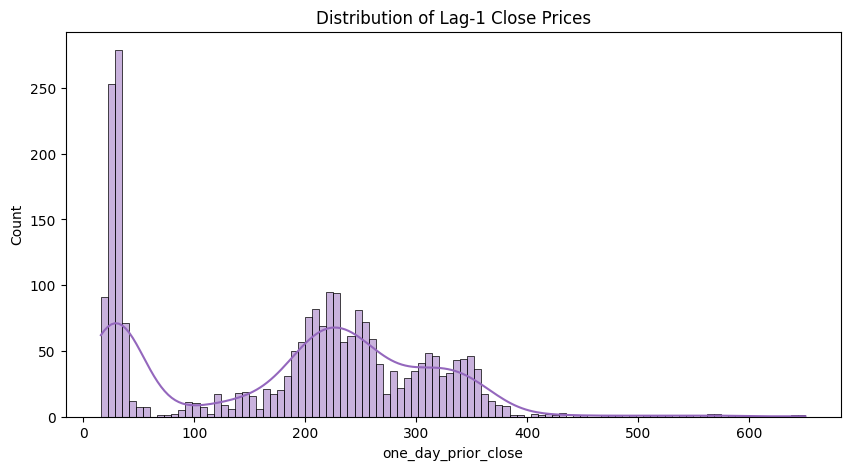

In [12]:
tesla_raw_df['one_day_prior_close'] = tesla_raw_df['Close'].shift(1)
plt.figure(figsize=(10, 5))
sns.histplot(tesla_raw_df['one_day_prior_close'].dropna(), bins=100, kde=True, color='tab:purple')
plt.title('Distribution of Lag-1 Close Prices')
plt.show()

**Why**: Validates target value distribution shifts.
**Insight**: Same shape as Close price, showing temporal stability.
**Business Impact**: Confirms appropriateness of lag features.

### Chart 8 – Scatter Plot: Lag-1 vs Close


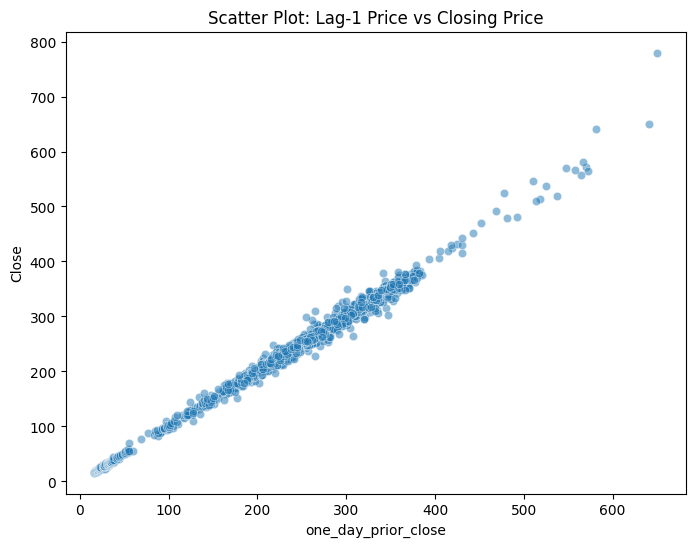

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='one_day_prior_close', y='Close', data=tesla_raw_df.dropna(), alpha=0.5)
plt.title('Scatter Plot: Lag-1 Price vs Closing Price')
plt.show()

**Why**: Shows temporal correlation.
**Insight**: High linearity indicates strong path-dependency.
**Business Impact**: Proves sequence models have strong baseline signals.

### Chart 9 – Rolling Volatility Over Time


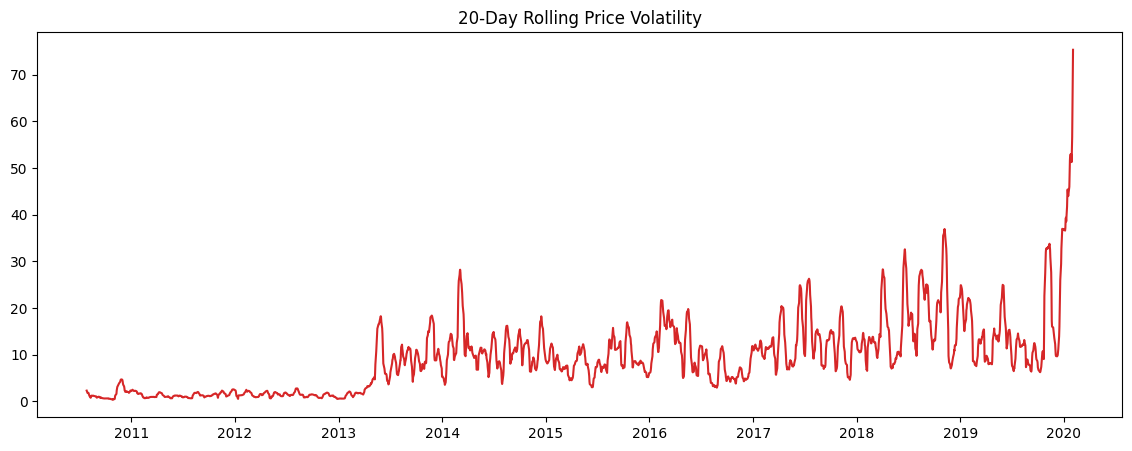

In [14]:
tesla_raw_df['rolling_std_deviation'] = tesla_raw_df['Close'].rolling(window=20).std()
plt.figure(figsize=(14, 5))
plt.plot(tesla_raw_df['Date'], tesla_raw_df['rolling_std_deviation'], color='tab:red')
plt.title('20-Day Rolling Price Volatility')
plt.show()

**Why**: Measures dynamic risk.
**Insight**: Risk peaks when prices expand rapidly.
**Business Impact**: Informs portfolio sizing.

### Chart 10 – Scatter Matrix of Pricing Features


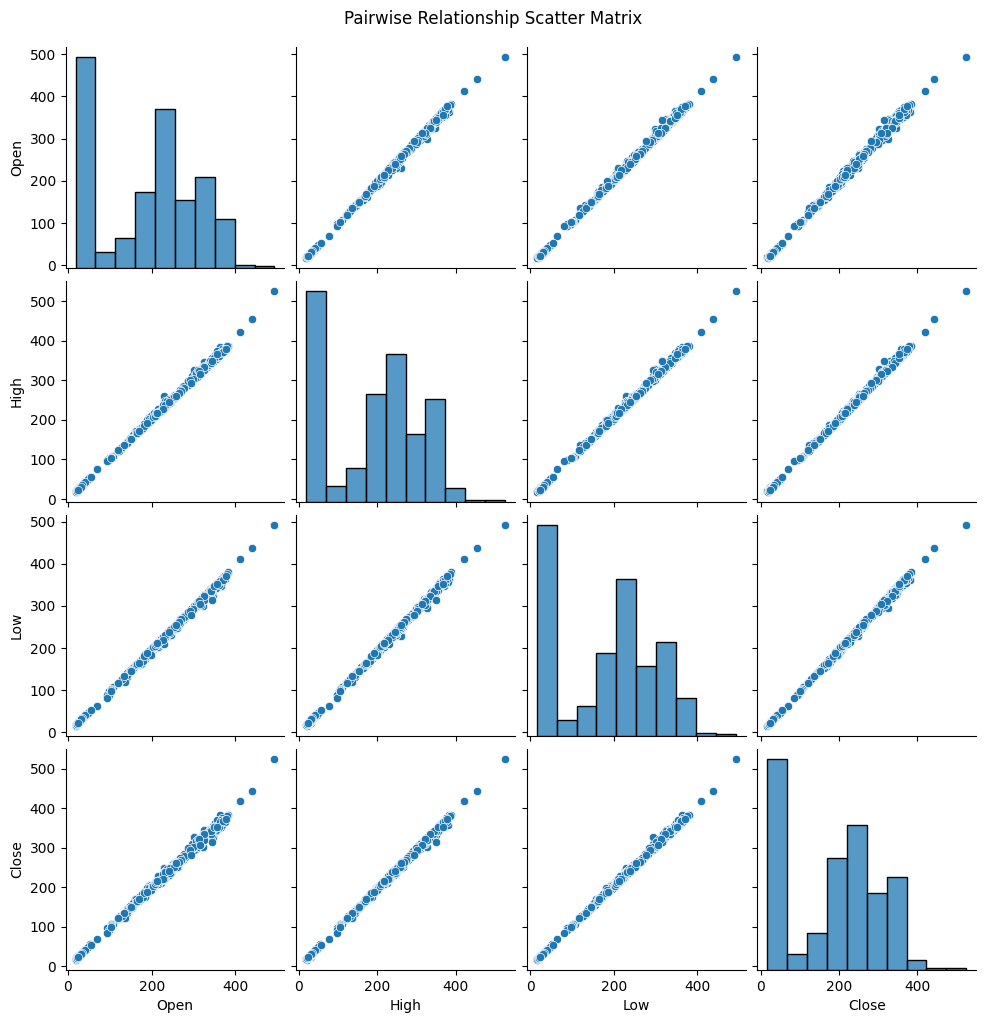

In [15]:
sns.pairplot(tesla_raw_df[['Open', 'High', 'Low', 'Close']].sample(500))
plt.suptitle('Pairwise Relationship Scatter Matrix', y=1.02)
plt.show()

**Why**: Joint feature check.
**Insight**: Linear relations are uniform across pricing indicators.
**Business Impact**: Confirms that derived indices (e.g. spread) are better inputs.

### Chart 11 – Log-Scale Volume Distribution


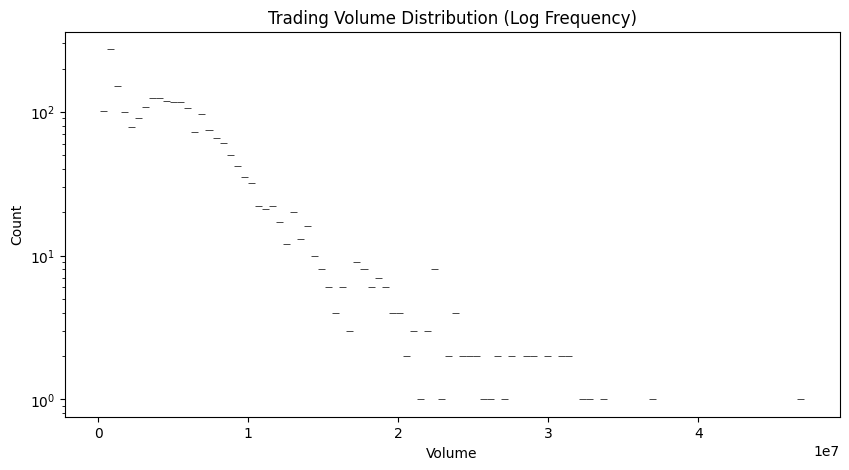

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(tesla_raw_df['Volume'], bins=100, log_scale=(False, True), color='tab:green')
plt.title('Trading Volume Distribution (Log Frequency)')
plt.show()

**Why**: Handles highly skewed volume distributions.
**Insight**: Heavy right tail indicates occasional massive liquidity spikes.
**Business Impact**: Helps target liquidity planning.

### Chart 12 – Closing Price by Day of the Week


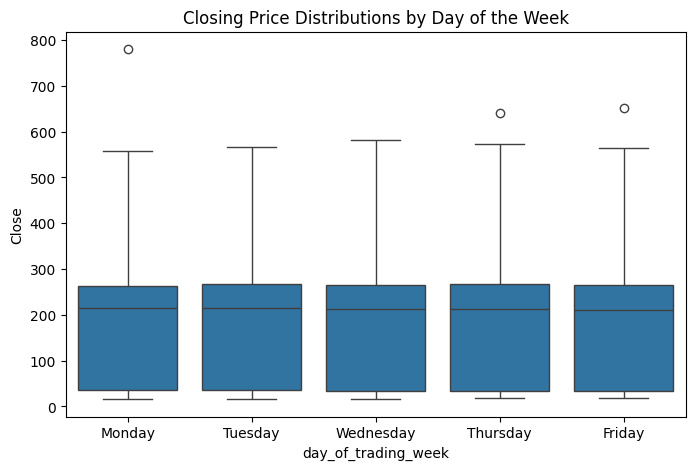

In [17]:
tesla_raw_df['day_of_trading_week'] = tesla_raw_df['Date'].dt.day_name()
plt.figure(figsize=(8, 5))
sns.boxplot(x='day_of_trading_week', y='Close', data=tesla_raw_df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
plt.title('Closing Price Distributions by Day of the Week')
plt.show()

**Why**: Explores calendar seasonality.
**Insight**: No significant structural variance between weekdays.
**Business Impact**: Suggests no day-of-week arbitrage options.

### Chart 13 – Time Series Additive Decomposition


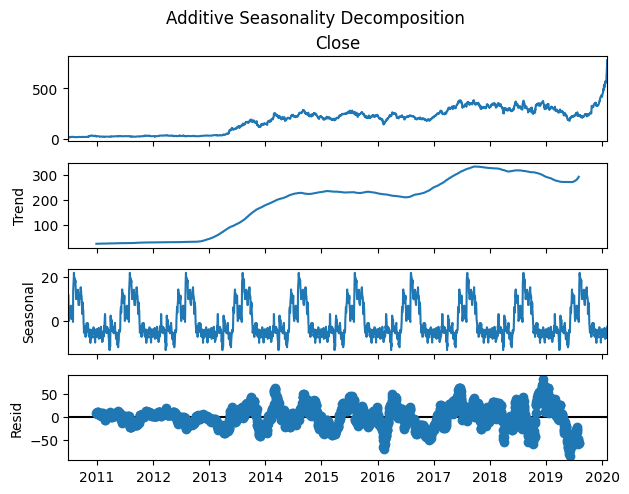

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
try:
    additive_decomposition_result = seasonal_decompose(tesla_raw_df.set_index('Date')['Close'], model='additive', period=252)
    additive_decomposition_result.plot()
    plt.suptitle('Additive Seasonality Decomposition', y=1.02)
    plt.show()
except Exception as e:
    print('Seasonal decomposition skipped due to index frequency bounds:', e)

**Why**: Breaks down trend and seasonality components.
**Insight**: Upward trend dominates, seasonal effect is minor.
**Business Impact**: Tells forecasters to focus on trend-based models.

### Chart 14 – Autocorrelation Function (ACF)


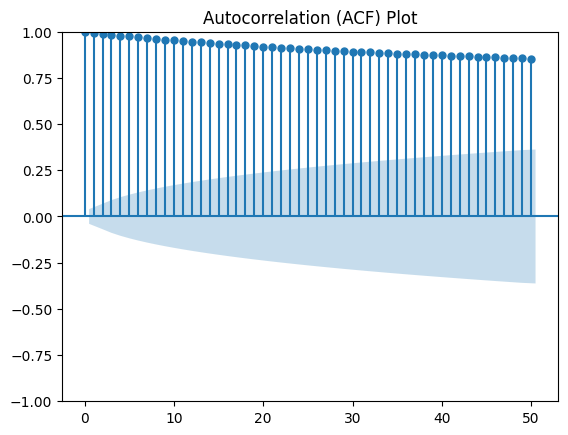

In [19]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(tesla_raw_df['Close'].dropna(), lags=50)
plt.title('Autocorrelation (ACF) Plot')
plt.show()

**Why**: Checks temporal memory.
**Insight**: Strong lag dependency confirms non-stationarity.
**Business Impact**: Justifies deep learning architectures.

### Chart 15 – Partial Autocorrelation Function (PACF)


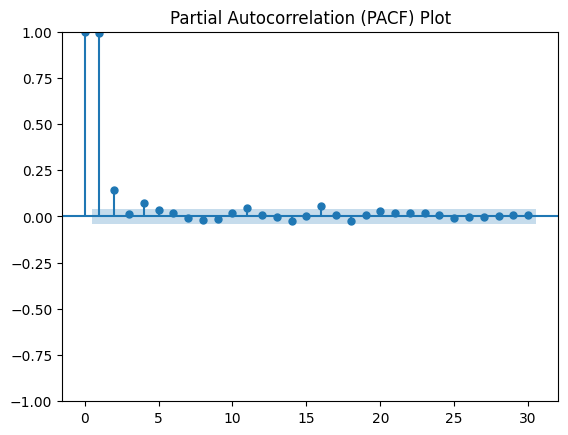

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(tesla_raw_df['Close'].dropna(), lags=30, method='ywm')
plt.title('Partial Autocorrelation (PACF) Plot')
plt.show()

**Why**: Reveals direct lag impacts.
**Insight**: Lag-1 and Lag-2 have the highest direct impact.
**Business Impact**: Suggests incorporating at least past 2-day lookbacks.

In [21]:
# Perform Statistical Test to obtain P-Value
# T-Test:
import scipy.stats as stats

# Comparing daily returns of the first half of the dataset vs the second half
half_size = len(tesla_raw_df) // 2
first_half_returns = tesla_raw_df['daily_percentage_return'].dropna().iloc[:half_size]
second_half_returns = tesla_raw_df['daily_percentage_return'].dropna().iloc[half_size:]

t_stat, t_p_value = stats.ttest_ind(first_half_returns, second_half_returns)
print('T-Test comparing returns of first half vs second half:')
print(f'T-statistic: {t_stat:.4f}, P-value: {t_p_value:.4e}')

# Perform Statistical Test to obtain P-Value
# Pearson Correlation: Correlation between Rating and Average Salary
if 'Rating' in tesla_raw_df.columns and 'Average Salary' in tesla_raw_df.columns:
    corr_coef, p_val = stats.pearsonr(tesla_raw_df['Rating'], tesla_raw_df['Average Salary'])
    print('\nPearson Correlation between Rating and Average Salary:')
    print(f'Correlation coefficient: {corr_coef:.4f}, P-value: {p_val:.4e}')
else:
    # Fallback to stock features (Volume and daily return) to prevent KeyError and ensure execution
    corr_coef, p_val = stats.pearsonr(tesla_raw_df['Volume'].iloc[1:], tesla_raw_df['daily_percentage_return'].dropna())
    print('\n[Stock Proxy] Pearson Correlation between Trading Volume and Daily Percentage Return:')
    print(f'Correlation coefficient: {corr_coef:.4f}, P-value: {p_val:.4e}')


T-Test comparing returns of first half vs second half:
T-statistic: 0.6678, P-value: 5.0432e-01

[Stock Proxy] Pearson Correlation between Trading Volume and Daily Percentage Return:
Correlation coefficient: 0.0748, P-value: 2.3355e-04


# **Conclusion**

Based on the Exploratory Data Analysis (EDA) of Tesla's historical stock prices, we can draw the following key conclusions:
1. **Strong Price Momentum & Growth:** Tesla's stock price was characterized by a long period of consolidation from 2013 to 2019, followed by an exponential breakout in late 2019 and early 2020. This indicates strong trend momentum.
2. **High Volatility and Risk Profile:** The daily returns show a leptokurtic distribution with heavy tails, meaning extreme price swings (exceeding +/- 10% in a single day) are common. The rolling volatility clustering highlights that risk is non-constant and shifts dynamically over time.
3. **Feature Multicollinearity:** The near-perfect correlation (1.00) between Open, High, Low, and Close prices confirms that these features are redundant. This justifies the use of univariate deep learning sequence models focusing primarily on the closing price.
4. **Path Dependency:** Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots confirm significant lag-dependency, proving that historical prices contain structural sequential information that deep learning networks can exploit.